# 第5回：アリコロニー最適化（Ant Colony Optimization, ACO）

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rsimd/NITIC-ConbinatorialOptimization/blob/master/lecture05_aco_tsp.ipynb)

このノートでは、グラフ／距離行列上の **旅行商人問題（TSP）** を題材に、最も素朴な系である **Ant System（AS）** 型のアリコロニー最適化を、**クラスひとつ** の実装として追う。**フェロモン** と **ヒューリスティック（距離の逆数）** から決まる遷移確率を見ながら、複数のアリエージェントが **どの都市へ進みやすいか** を図として理解することをねらう。

群知能の整理と PSO との対比は、[第4回・§2（群知能アルゴリズムの例）](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture04-pso#sec-pso-ch2) と [§3（PSO）](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture04-pso#sec-pso-ch3)、および [外部まとめ（PSO／ACO）](https://jkushida.github.io/ai-arch/docs/pso_summary.html) が参考になる。組合せ最適化の位置づけは [第1回・導入](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture01-intro-optimization) を参照。

---


## 0. このノートで学ぶこと

1. Ant System で用いられる **フェロモン $\tau_{ij}$** と **蒸発率 $\rho$** が探索に与える意味。
2. アリが **未完走のとき** に、未到達の都市 $j$ へ進む離散確率が、後述の **式 (2)** とどう対応するか。
3. 一周が終わったあと（**全アリがツアーを完成させたあと**）にだけ起きる **蒸発と堆積** と、コードの対応。
4. **可視化** として、(a) **辺フェロモン** の強弱、(b) ある一歩で **どの次ノードが選ばれやすいか**、(c) 反復による **最短ツアー長の推移** を読む。
5. ヒューリスティクスゆえに **最適解の保証はない** こと、および **パラメータ依存** に触れる。
6. [第4回の PSO](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture04-pso) と **何が異なりどちらが何に向くか**（[§6（対照）](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture05-aco-tsp#sec-aco-pso-compare)）。
7. **同一インスタンスの TSP** を ACO と PSO で解く **課題の手順**（[§7（課題）](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture05-aco-tsp#sec-aco-assignment)）。

---


(sec:aco-bg)=

## 1. はじめに：なぜ ACO が「順路」を扱うのか

**アリコロニー最適化（ACO）** は、アリが **フェロモンという痕跡** を辺に残し、それを後続のアリが参照するという **正のフィードバック** をモデル化した手法である。[第4回ノートの §2](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture04-pso#sec-pso-ch2) で短く触れた直感――短い経路ほど往来が速く、その辺にフェロモンが溜まりやすい――を、離散グラフに写像したものとして捉えるとよい。

ここでの **エージェント** は「**アリ**」である。ひとりのアリは **都市の順列をランダムに増築** していく。**皆さんはどう思うだろうか？** 一見、単なるランダムウォークに見えるが、**多数のアリの試行** と **時間方向の更新** が重なることで、有望な辺に探索のバイアスがかかる。

---


[Wikipedia（日本語）「蟻コロニー最適化」の解説](https://ja.wikipedia.org/wiki/%E8%9F%BB%E3%82%B3%E3%83%AD%E3%83%8B%E3%83%BC%E6%9C%80%E9%81%A9%E5%8C%96)（その中でこの図が例として使われる。画像本体は Wikimedia Commons） である。**蜂蜜（少数・高評価）** と **薄い糖水（多数・評価は低め）** の前で、コロニーとしてどこに資源を集中させるかをアリが表しており、「制約つきで良い選択を並べる」ところが **組合せ最適化と橋渡しできる比喩** である。

![Knapsack ants（ナップザック問題とアリの比喩）](https://upload.wikimedia.org/wikipedia/commons/e/ec/Knapsack_ants.svg)

**クレジット**: [Commons — File:Knapsack ants.svg](https://commons.wikimedia.org/wiki/File:Knapsack_ants.svg)（Inkscape で作成、[Dake](https://commons.wikimedia.org/wiki/User:Dake~commonswiki)）[CC BY-SA 2.5](https://creativecommons.org/licenses/by-sa/2.5/deed.ja)。

---


(sec:aco-soft)=

## ……イメージを言葉で（式に入る前に）

**ふわっとした見立て** だけ先に書いておく。アリは教室で頭をひねって「最短になる定理」を議論しているわけではない。それでも往来の結果として、経路沿いにはかすかな **痕跡**（フェロモン）が残り、その痕跡に **そっと引き寄せられる** ような足どりが続く。この「環境側のメモ」「足の側のゆるやかさ」だけを心にとめてほしい。

図にある **蜂蜜と糖水** は、問題設定が違うが **ニュアンス** は近い。こちら側に足が寄りやすい、評価の高い側に協調した探索が張りつきやすい、という光景を頭の映画で見ておけると、このあとの式読みが楽になる。このノートの TSP では「甘さ」そのものではなく **距離の短さがよい評価** になっているだけだという点だけ、取り換えなくてよい。

**蒸発** は、痕跡が **過去の成功だけに張りつき続けない** よう時間をゆるめる働きと捉えることができる。**堆積** は、ひとたちが実際に歩いたあとに、環境が **ログを増幅する** ところにある。

つぎに **記号だけに切り替えて**、「痕跡」が $\tau_{ij}(t)$ で、「ゆるめる」が $(1-\rho)$ で、「評価のよい試行ほど増える」が $Q/L_k$ としてどう並ぶかを書く。**皆さんはどう思うだろうか？** 式は冷たく見えるが、いまの映画の **言い換え** にすぎないのだ、と思いながら読んでもらえれば十分である。

---


(sec:aco-model)=

## 2. 対称 TSP と Ant System の式


### 2.1 問題

頂点を $\{0,1,\ldots,n-1\}$ と番号付け、その上の対称ネットワークを距離行列 $d_{ij}=d_{ji}\ge 0$ で与える。**プログラム上は**、この $d_{ij}$ を並べた **`n\times n` の NumPy 配列 `dist`** とみなせばよい。成分 `dist[i, j]` が数学の $d_{ij}$ に対応する（インデックスは 0 始まりで慣れた形にしている）。

対角 $d_{ii}$ は「都市 $i$ から自分へ」という辺であり、順路構築の途中で不必要に選ばれないように、実装では **`np.inf`** のような **十分大きな数** で埋める。それ以外も非負であるとしてよい。このノート末尾の **`demo`** では、各都市に座標ベクトル `xy[k]`（単位正方形上の実ベクトル）を与え、$d_{ij}=\lVert xy[i]-xy[j]\rVert_2$（ユークリッド距離）として `dist` を組み立てる。その場合も、距離算出のあと **`np.fill_diagonal(dist, np.inf)`** の一行が式の $d_{ii}$ と対応する。

目標は、各頂点をちょうど一度ずつめぐって戻ってくる **ハミルトン閉路** のうち、**全辺の距離の和** が最小になるものを近似して求めることである。


### 2.2 ヒューリスティック情報とは何か

$$
\eta_{ij}=\frac{1}{\max(\varepsilon,d_{ij})}
\tag{1}
$$

**ヒューリスティック情報** $\eta_{ij}$ は、距離だけから計算できる **問題固有の係数** である。**役割は一つだけ**であり、フェロモンがまだ弱いときでも「**無粋にも近そうな辺へ足を運びやすい**」ような **事前バイアス** を式 (2) の分子につけることにある。$\eta_{ij}$ が **大きい**と $i\to j$ へ進む質量が上がり、**距離だけ見れば greedy に近い**行動になりやすい。

式 (2) でいう $\eta_{ij}^{\beta}$ がそのスイッチである。クラス **`AntColonyTSP`** では、`_move_weights` の中で毎回 `eta = 1.0 / max(self._eps, self._dist[i, j])` として **別配列としては保持せず都度算出**しているが、数理モデルとしての $\eta_{ij}$ は常にこの式である。

$\varepsilon$ はゼロ除算だけを避けるための微小な正である（距離そのものとは独立に課した安全装置である）。


### 2.3 状態 $\tau_{ij}(t)$ とプログラム上の対応物

順序付きペア $(i,j)$ に非負の **フェロモン** $\tau_{ij}(t)\ge 0$ を載せる。ここで $t\in\{0,1,2,\ldots\}$ は **アルゴリズムの離散反復** を数えるカウンタと思えばよい（実装上は「カウンター変数」としては明示せず、`iterate()` を繰り返すたびに配列だけが書き換わっている）。

対称な TSP では、環境側のモデルでも実装でも **$(i,j)$ と $(j,i)$ に同値のフェロモン** を載せてよい。このノートでは **`tau` と名付けられた `dist` と同じ形の正方配列 `self._tau`** が $\tau_{ij}(t)$ のスナップショットであり、`tau[i,j]` が $\tau_{ij}$ に対応する。初期状態では **全要素を小さな正の定数 $\tau_{0}$**（例：`1e-6`）で埋め、`iterate()` の末尾で **まず全域に蒸発、そのあと複数のアリによる堆積**が加わって更新されていく。

`plot_state` の右側に示すヒートマップは、まさにこの正方行列 **`colony.tau`** を画像化したものである。


### 2.4 ツアー構築と遷移確率のコード対応

反復の内部で、アリ $k$ が現在都市 $i$ にいるとする。まだ一度も訪れていない頂点だけを許可された次候補 $U_k(i)$ とする（始点への戻りは、順路が一周する直前だけ必要になるので、コードでは閉じたリストの **最終辺** として処理している）。

$$
p_{ij}^k(t)=
\frac{[\tau_{ij}(t)]^{\alpha}\,[\eta_{ij}]^{\beta}}
{\sum_{\ell\in U_k(i)}[\tau_{i\ell}(t)]^{\alpha}\,[\eta_{i\ell}]^{\beta}}
\quad (j\in U_k(i))
\tag{2}
$$

$U_k(i)$ 外への確率質量はゼロとする。**`build_tour`** メソッドは、この正規化分布に従って `numpy.random.choice` で次の都市を引き、リストに追加していくだけである。`_move_weights` が式 (2) に対応する **未正規化の重みベクトル** を返している。

係数 $\alpha\ge 0$ はフェロモンを読む強さ、$\beta\ge 0$ は距離ヒューリスティックを読む強さである。**$\rho$ とは別次元**であり、どちらも「探索と強い引き込み」のトレードオフには効くが、意味は異なるので混同しないようにしたい。


### 2.5 蒸発と堆積

まず蒸発。$0<\rho<1$ とする。

$$
\tau_{ij}(t+1)=(1-\rho)\,\tau_{ij}(t)
\tag{3}
$$

**実装上は** `iterate` のフェロモン更新の冒頭で `self._tau *= (1.0 - self._rho)` の一行として現れる。行列の **すべての成分** が一括で減衰する。

次に、この反復でアリ $k$ が得た順路長を $L_k$、定数 $Q>0$ を用いて

$$
\Delta\tau_{ij}^k=
\begin{cases}
\dfrac{Q}{L_k} & (i,j)\text{ が }k\text{ のクローズド順路に含まれるとき}\\
0 & \text{それ以外}
\end{cases}
\tag{4}
$$

として堆積し、すべてのアリについて和をとる：

$$
\tau_{ij}(t+1)\leftarrow \tau_{ij}(t+1)+\sum_k \Delta\tau_{ij}^k
\tag{5}
$$

対称な **TSP** なので、順路が辺 $(i,j)$ を使えばコードでは **`tau[a,b]` と `tau[b,a]` に同じ量** を足してよい。**短い順路ほど $\Delta\tau$ が大きい**ため、質のよい試行ほど環境側のログが濃く残るように設計されている。式の順序としては、(3) のあとに (5) を足せば、このノートの実装そのものである。

記述の順序は文献によって前後することがあるが、**「複数試行してから環境だけを更新する」**という骨格だけは共通である。

---


(sec:aco-pseudo)=

## 3. Ant System の疑似コード


In [ ]:
from IPython.display import HTML, display

ACO_TSP_PSEUDOCODE_URL = "/NITIC-ConbinatorialOptimization/assets/lecture05_aco_tsp_pseudocode.html"

display(
    HTML(
        f"""
    <iframe
      class="aco-tsp-pseudocode-frame"
      src="{ACO_TSP_PSEUDOCODE_URL}"
      title="Ant System の疑似コード"
      loading="lazy"
    ></iframe>
    """
    )
)


並列処理の順序や、開始都市の与え方、局所探索の併用などは **アルゴリズム亜種（ACS・MMAS など）** で変わりうる。このノートは **AS の骨格** に焦点を絞っている。

---


(sec:aco-code)=

## 4. 実装：`AntColonyTSP` と可視化

**この資料では、コードの説明文はすべて「そのコードセルの直前の Markdown セル」にのみ書いてある。** ここには節としての見出しと、セルの並びだけを示す。

実行は **§4.1 の Markdown のすぐ下のセルから**、順に実行するとよい。

1. §4.1 ライブラリの読み込み → （コードセル）
2. §4.2 TSP をどうコード化しているか（Markdown のみ：`dist` と逐次構築）
3. §4.3 核 `AntColonyTSP` → （コードセル）
4. §4.4 描画ヘルパ → （コードセル）
5. §4.5 まとめて試す `demo` → （コードセル）

---


### 4.1 ライブラリの読み込み

**NumPy** で距離行列や乱数を扱い、**Matplotlib** で地図・行列・アニメーションを描く。日本語の軸ラベルやタイトルが化ける環境では `matplotlib-fontja` を試し、利用できなければサンセリフ系フォントに退避する。**このセルを最初に実行**しておくと、以降のセルで `np` や `plt` が未定義になる事故を防げる。

**Google Colab** で日本語フォントだけ不足しているときは、**このマークダウンより上に**コードセルを挿入して `!pip install matplotlib-fontja` を一度走らせてもよい（本リポジトリの `pyproject.toml` にも同パッケージを記してある）。


In [16]:
"""対称 TSP 上の Ant System（AS）をシンプルなクラスで実装する。"""

from __future__ import annotations

import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import animation

try:
    import matplotlib_fontja  # noqa: F401

    matplotlib_fontja.japanize()
except Exception:
    plt.rcParams["font.family"] = "sans-serif"


(sec:aco-tsp-coding)=

### 4.2 このノートにおける TSP のコーディング（GA／PSO で手こずりやすい点との違い）

**問題インスタンス**は、都市番号 $0,\ldots,n-1$ と **`n\times n` の距離行列 `dist` だけで与えている。** 座標 `xy` が出てくるのは `demo` が幾何から `dist` を組み立てる便宜にすぎず、**`AntColonyTSP` は `_dist` にしか依存しない。** これは重み付き完全グラフとしての TSP をそのままコード化した形である。

**解（ツアー）**は、順列染色体や連続ベクトルではなく、`build_tour` が構築する **`list[int]` の閉じた順路**（例：`[3,1,4,2,0,3]`）。`visited` という真偽ベクトルで未訪問を管理し、式 (2) に従って **合法な次都市だけ**から `numpy.random.choice` で進む **逐次構築**である。長さは **隣接ペアを `dist[a,b]` で足すだけ**である。

**ここが GA や PSO で TSP を実装するときに比べて楽な点である。** GA では順列を染色体にすると、雑な交叉は **都市の重複や取りこぼし**を生み、**順列専用の交叉（OX／PMX など）や修復**が必要になりやすい。PSO はもともと連続ベクトル上の更新であり、TSP のように **離散の順序** を直接は扱えず、[第4回ノート](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture04-pso) で触れたように **Random Keys や別表現で「粒子 $
ightarrow$ 順路」へ写像する工夫**がレイヤとして要る。

それに対して本ノートの Ant System は **`allowed = ~visited` で候補を切り、構築途中は常にハミルトン路**のまま進む。順路制約を **事後的に満たすルーチンを書かなくてよい**点が、コード量とデバッグのしやすさにつながっている。

以下はそのコアであり、直後のコードセルにある `build_tour` がこの流れをそのまま実装している。

```python
visited = np.zeros(n, dtype=bool)
path = [start]
visited[start] = True
cur = start
while visited.sum() < n:
    allowed = ~visited
    w = self._move_weights(cur, allowed)  # 式 (2) に相当する重み（正規化前）
    idx = np.flatnonzero(allowed)
    pj = w[idx] / w[idx].sum()
    nxt = int(self._rng.choice(idx, p=pj))
    path.append(nxt)
    visited[nxt] = True
    cur = nxt
path_closed = path + [path[0]]
length = float(sum(self._dist[a, b] for a, b in zip(path_closed, path_closed[1:])))
```


### 4.3 核：`AntColonyTSP`（Ant System のそのままの実装）

内部に距離行列 `_dist` とフェロモン行列 `_tau` を持つ。`_move_weights` と `build_tour` が、式 **(2)** に相当する確率質量へ従って**未到達都市へ順に進む**部分である。`iterate` は疑似コードどおりに、**複数アリのツアー生成 → 反復最短の記録 → 蒸発 ($(1-\rho)$) → $Q/L$ に比例した堆積**までをひとつの反復としてまとめる。`step_probabilities` は「いまこの一歩で式 (2) は何を言っているか」を**棒グラフ用**に取り出す窓口にすぎない。


In [17]:
class AntColonyTSP:
    """Ant System による対称 TSP の近似（距離行列のみを見る）。"""

    def __init__(
        self,
        dist: np.ndarray,
        *,
        n_ants: int = 20,
        alpha: float = 1.0,
        beta: float = 4.0,
        rho: float = 0.5,
        q: float = 100.0,
        tau_init: float | None = None,
        eps: float = 1e-9,
        seed: int | None = 0,
    ) -> None:
        self._dist = np.asarray(dist, dtype=float)
        if self._dist.ndim != 2 or self._dist.shape[0] != self._dist.shape[1]:
            raise ValueError("dist は正方行列である必要がある")
        self._n = int(self._dist.shape[0])
        self._alpha = float(alpha)
        self._beta = float(beta)
        self._rho = float(rho)
        self._q = float(q)
        self._eps = float(eps)
        self._n_ants = int(n_ants)
        self._rng = np.random.default_rng(seed)
        t0 = 1e-6 if tau_init is None else float(tau_init)
        self._tau = np.full_like(self._dist, t0)

    @property
    def tau(self) -> np.ndarray:
        return self._tau

    def _move_weights(self, i: int, allowed: np.ndarray) -> np.ndarray:
        w = np.zeros(self._n)
        idx = np.flatnonzero(allowed)
        if idx.size == 0:
            return w
        t = np.maximum(self._tau[i, idx], 1e-12)
        eta = 1.0 / np.maximum(self._eps, self._dist[i, idx])
        w[idx] = (t**self._alpha) * (eta**self._beta)
        s = float(w.sum())
        if s <= 0.0:
            w[idx] = 1.0 / idx.size
            return w
        return w / s

    def build_tour(self, start: int | None = None) -> tuple[list[int], float]:
        """クローズドツアーをランダム逐次生成し、長さを返す。"""

        n = self._n
        if start is None:
            start = int(self._rng.integers(0, n))
        visited = np.zeros(n, dtype=bool)
        path: list[int] = [int(start)]
        visited[start] = True
        cur = int(start)
        while visited.sum() < n:
            allowed = ~visited
            w = self._move_weights(cur, allowed)
            idx = np.flatnonzero(allowed)
            if idx.size == 0:
                break
            pj = w[idx]
            pj = pj / pj.sum()
            nxt = int(self._rng.choice(idx, p=pj))
            path.append(nxt)
            visited[nxt] = True
            cur = nxt
        path_closed = path + [path[0]]
        length = 0.0
        for a, b in zip(path_closed, path_closed[1:]):
            length += float(self._dist[a, b])
        return path_closed, length

    def step_probabilities(self, i: int, visited: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """可視化用：現在ノード i から次に行けるノードの確率を返す。"""

        allowed = ~visited
        w = self._move_weights(i, allowed)
        idx = np.flatnonzero(allowed)
        pj = w[idx]
        if pj.sum() > 0:
            pj = pj / pj.sum()
        return idx.astype(int), pj

    def iterate(self) -> tuple[float, list[int], list[tuple[list[int], float]]]:
        """1 反復：全アリがツアーを作り、最短を記録し、τ を更新する。"""

        trials: list[tuple[list[int], float]] = []
        best_l = math.inf
        best_path: list[int] | None = None

        for _ in range(self._n_ants):
            path, length = self.build_tour()
            trials.append((path, length))
            if length < best_l:
                best_l = length
                best_path = list(path)

        assert best_path is not None

        self._tau *= 1.0 - self._rho
        for path, length in trials:
            contrib = self._q / max(length, self._eps)
            for a, b in zip(path, path[1:]):
                self._tau[a, b] += contrib
                self._tau[b, a] += contrib

        return best_l, best_path, trials

    def run(self, n_iter: int) -> tuple[list[float], list[int]]:
        """反復を繰り返し、各反復末のグローバルベスト長の履歴を返す。"""

        hist: list[float] = []
        global_best = math.inf
        global_path: list[int] = []
        for _ in range(n_iter):
            b_l, b_p, _ = self.iterate()
            hist.append(b_l)
            if b_l < global_best:
                global_best = b_l
                global_path = b_p
        return hist, global_path

### 4.4 描画ヘルパ（地図・アニメ・意思決定バー）



- **`plot_state`**：左パネルで全辺に薄い灰色を敷き、その太さで**フェロモンの相対強度**を表す。赤の閉路が**その時点での累積ベスト順路**である。右は **$\tau$ のヒートマップ**である。

- **`draw_cumulative_best_tour` / `show_best_tour_evolution_animation`**：反復インデックスに同期して、**累積ベスト経路の形**がどう入れ替わるかを `FuncAnimation` で再生する。ノートブックでは `to_jshtml()` でブラウザ内プレーヤに埋め込む想定である。

- **`plot_decision_bar`**：未完走の状態で、式 (2) が与える**次都市の確率**を棒グラフにする。



いずれも厳密解の証明ではなく、**挙動の説明**のためのコードである。


In [18]:
def plot_state(
    xy: np.ndarray,
    colony: AntColonyTSP,
    best_path: list[int],
    title: str,
    iteration_label: str,
) -> plt.Figure:
    fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.0))
    axm, axh = axes
    tau = colony.tau
    tnorm = tau / max(tau.max(), 1e-12)

    n = xy.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            lw = 0.4 + 3.8 * float(tnorm[i, j])
            axm.plot(
                [xy[i, 0], xy[j, 0]],
                [xy[i, 1], xy[j, 1]],
                color="#bdbdbd",
                lw=lw,
                alpha=0.35,
            )

    bp = best_path[:-1]
    nbp = len(bp)
    for k in range(nbp):
        a = bp[k]
        b = bp[(k + 1) % nbp]
        axm.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]], color="#d7191c", lw=2.2, alpha=0.92)

    axm.scatter(xy[:, 0], xy[:, 1], c="#313695", s=130, zorder=5, edgecolor="white", linewidths=0.6)
    for kk, (x, y) in enumerate(xy):
        axm.text(x + 0.05, y + 0.05, str(kk), fontsize=9, color="#313695")


    axm.set_aspect("equal", adjustable="datalim")
    axm.set_title(title)
    axm.grid(True, linestyle=":", alpha=0.45)

    im = axh.imshow(tau, cmap="YlOrBr", aspect="equal")
    axh.set_title("フェロモン行列 τ（色が濃いほど強い）")
    fig.colorbar(im, ax=axh, fraction=0.046, pad=0.04)
    fig.suptitle(iteration_label, fontsize=11, y=1.02)
    fig.tight_layout()
    return fig


def draw_cumulative_best_tour(
    ax: plt.Axes,
    xy: np.ndarray,
    path_closed: list[int],
    step_t: int,
    cum_best_length: float,
) -> None:
    """各反復の「累積ベスト」の閉路だけを単純に描画する（アニメーション用）。"""

    ax.clear()
    n = xy.shape[0]
    bp = path_closed[:-1]
    nb = len(bp)
    if nb >= 2:
        for k in range(nb):
            a, b = bp[k], bp[(k + 1) % nb]
            ax.plot(
                [xy[a, 0], xy[b, 0]],
                [xy[a, 1], xy[b, 1]],
                color="#d7191c",
                lw=2.4,
                alpha=0.95,
                zorder=2,
            )
    ax.scatter(
        xy[:, 0],
        xy[:, 1],
        c="#313695",
        s=140,
        zorder=5,
        edgecolor="white",
        linewidths=0.7,
    )
    for i, (x, y) in enumerate(xy):
        ax.text(float(x + 0.04), float(y + 0.04), str(i), fontsize=9.5, color="#313695", zorder=6)
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(True, linestyle=":", alpha=0.45)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.set_title(
        "累積ベスト順路　"
        rf"反復 $t={step_t}$ 終了直後　長さ $={cum_best_length:.4f}$"
    )


def show_best_tour_evolution_animation(
    xy: np.ndarray,
    paths_hist: list[list[int]],
    cum_lengths: list[float],
    *,
    interval_ms: int = 240,
    figsize: tuple[float, float] = (6.2, 5.8),
    repeat: bool = True,
) -> None:
    """反復ステップごとに累積ベスト順路がどう見えるか ``FuncAnimation`` で再生する。

    Jupyter / Google Colab では ``IPython.display.HTML(anim.to_jshtml())`` を優先する。
    """

    fig, ax = plt.subplots(figsize=figsize)
    plt.tight_layout()

    def _update(ti: int) -> None:
        draw_cumulative_best_tour(ax, xy, paths_hist[ti], step_t=ti, cum_best_length=float(cum_lengths[ti]))

    _update(0)
    ani = animation.FuncAnimation(
        fig,
        _update,
        frames=len(paths_hist),
        interval=interval_ms,
        repeat=repeat,
        blit=False,
    )

    try:
        from IPython.display import HTML, display
        from IPython import get_ipython as _ipython_get_ipython
    except ImportError:
        _ipython_get_ipython = None

    if _ipython_get_ipython is not None and _ipython_get_ipython() is not None:
        html = ani.to_jshtml(default_mode="loop" if repeat else "once")
        plt.close(fig)
        display(HTML(html))
        return

    plt.close(fig)
    nfr = len(paths_hist)
    k = min(nfr, 8)
    axes_idx = sorted({min(nfr - 1, max(0, int(round(j)))) for j in np.linspace(0, nfr - 1, k)})
    ncol = 4
    nrow = int(math.ceil(len(axes_idx) / ncol))
    fig_strip, axes_ar = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 3.3 * nrow))
    flat_axes = np.atleast_1d(axes_ar).ravel()
    for kix, ti in enumerate(axes_idx):
        draw_cumulative_best_tour(
            flat_axes[kix],
            xy,
            paths_hist[ti],
            step_t=ti,
            cum_best_length=float(cum_lengths[ti]),
        )
    for j in range(len(axes_idx), flat_axes.size):
        flat_axes[j].set_visible(False)
    fig_strip.suptitle("環境によっては JS が使えないため、複数ステップを静止画で並べる", fontsize=10)
    fig_strip.tight_layout()
    plt.show()
    plt.close(fig_strip)


def plot_decision_bar(
    colony: AntColonyTSP,
    current: int,
    visited: np.ndarray,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    if ax is None:
        _, ax = plt.subplots(figsize=(5.0, 2.8))
    idx, pj = colony.step_probabilities(current, visited)
    labs = [str(int(j)) for j in idx]
    ax.bar(labs, pj, color="#2c7bb6", alpha=0.85)
    ax.set_ylim(0.0, max(0.08, float(pj.max()) * 1.15))
    ax.set_xlabel("次に行く都市 j")
    ax.set_ylabel("確率")
    ax.set_title(f"現在都市 {current} からの遷移分布（未訪問のみ）")
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
    return ax


### 4.5 まとめて試す：`demo`

単位正方形内に **`n_node` 個**の都市をランダムに撒き（乱数種は `seed`）、ユークリッド距離の対称 TSP のインスタンスをつくる。`iterate` を所定回数だけ回し、その途中の**フェロモン＋ベスト順路**を静止画で抜き、続けて**ベスト順路の変形アニメ**、**単調に下がっていく累積ベスト長**、最後に**都市 0 からの遷移分布**を表示する。

**読みかたのヒント**：`n_node` や `n_ants` を変えると探索の難しさと更新の速さのトレードオフが変わる。セル末尾の `demo()` を実行すると図がまとめて出力される。


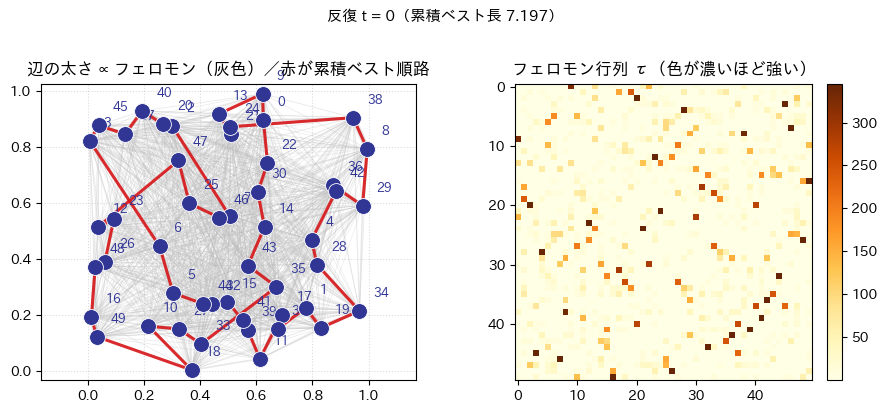

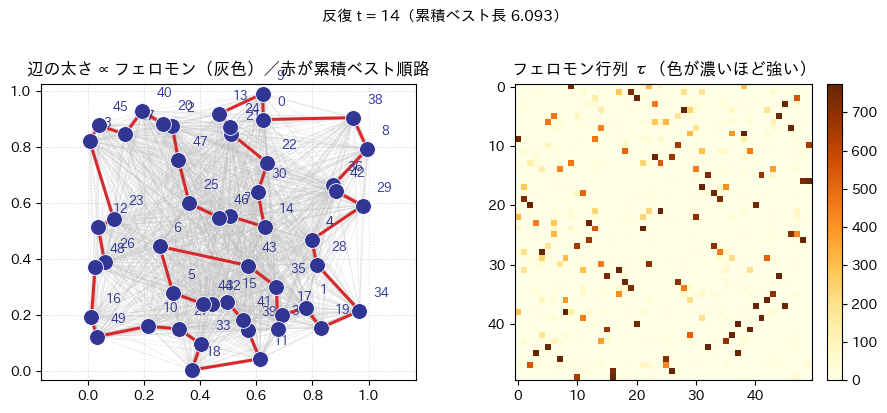

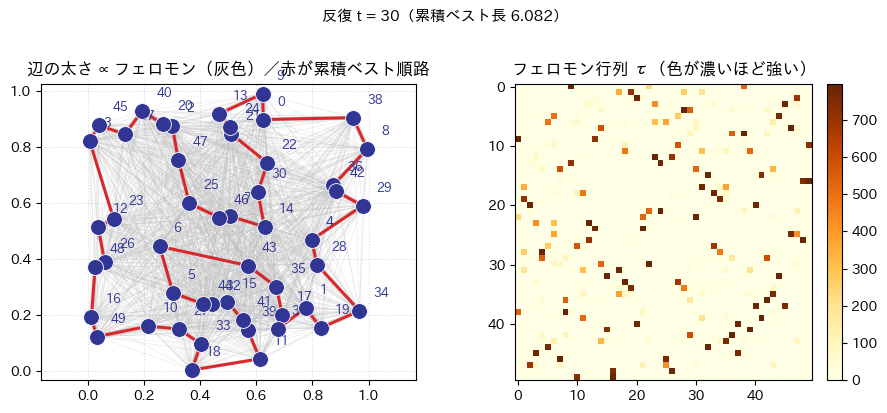

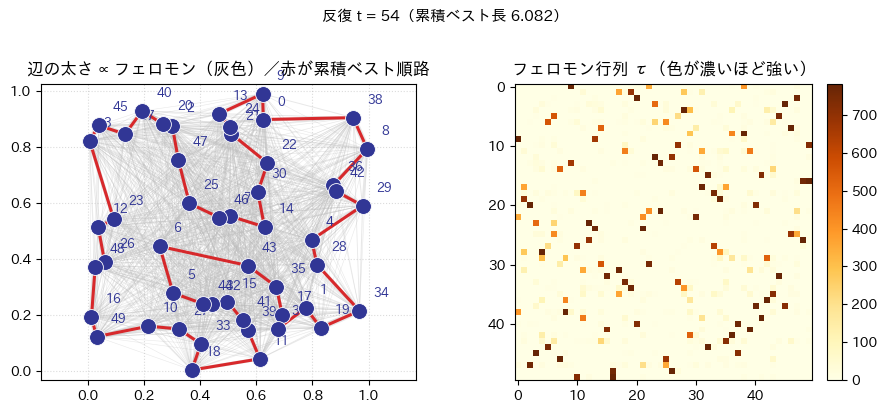

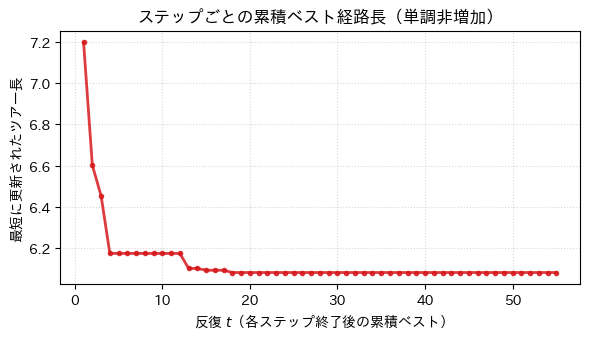

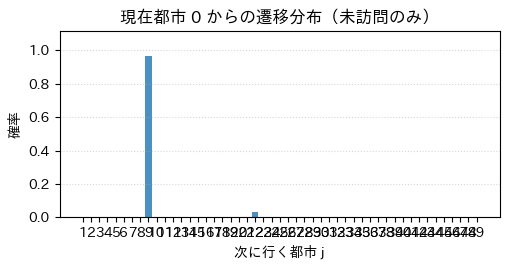

In [19]:
def demo(seed: int = 7,n_node: int = 50, n_ants: int = 32) -> None:
    """ユークリッド TSPを実行．都市をランダム配置で試し、収束の様子を観る。"""

    rng = np.random.default_rng(seed)

    xy = rng.uniform(0, 1, size=(n_node, 2))
    dist = np.linalg.norm(xy[:, None, :] - xy[None, :, :], axis=-1)
    np.fill_diagonal(dist, np.inf)

    # 探索空間が大きいのでアリ数と反復をやや増やす（体感で「更新が続く」ようにする）。
    colony = AntColonyTSP(dist, n_ants=n_ants, alpha=1.0, beta=5.0, rho=0.52, q=90.0, seed=1)

    n_iter_demo = 55
    snap_iters = {0, 14, 30, n_iter_demo - 1}
    cum_best = math.inf
    global_path: list[int] = []
    hist_cum: list[float] = []
    hist_paths_snap: list[list[int]] = []

    for t in range(n_iter_demo):
        b_l, b_p, _ = colony.iterate()
        if b_l < cum_best:
            cum_best = b_l
            global_path = list(b_p)
        hist_cum.append(cum_best)
        hist_paths_snap.append(list(global_path))

        if t in snap_iters:
            fig = plot_state(
                xy,
                colony,
                global_path,
                title="辺の太さ ∝ フェロモン（灰色）／赤が累積ベスト順路",
                iteration_label=f"反復 t = {t}（累積ベスト長 {cum_best:.3f}）",
            )
            plt.show()
            plt.close(fig)

    show_best_tour_evolution_animation(
        xy,
        hist_paths_snap,
        hist_cum,
        interval_ms=260,
        figsize=(6.0, 5.6),
        repeat=True,
    )

    fig_curve, ax = plt.subplots(figsize=(6.0, 3.5))
    ax.plot(range(1, len(hist_cum) + 1), hist_cum, color="#d7191c", lw=2.0, marker="o", ms=3, alpha=0.85)
    ax.set_xlabel("反復 $t$（各ステップ終了後の累積ベスト）")
    ax.set_ylabel("最短に更新されたツアー長")
    ax.set_title("ステップごとの累積ベスト経路長（単調非増加）")
    ax.grid(True, linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.close(fig_curve)

    visited = np.zeros(n_node, dtype=bool)
    visited[0] = True
    _, axb = plt.subplots(figsize=(5.2, 2.8))
    plot_decision_bar(colony, current=0, visited=visited, ax=axb)
    plt.tight_layout()
    plt.show()


demo()

(sec:aco-ref)=

## 5. あとがき：パラメータと限界

- $\beta$ を大きくすると **近い都市へ貪欲に寄る** 傾向が強まり、**局所解** に閉じ込められやすい。
- $\rho$ が大きすぎると **記憶が消えるのが速く**、有望な辺を保持しにくい。
- 本実装は **教科書レベルの AS** に留めてある。大規模 TSP では **MMAS** や **局所探索とのハイブリッド** などが実用で検討される。

典型文献として、Dorigo, Stützle, *Ant Colony Optimization*（MIT Press, 2004）などがある。

**皆さんはどう思うだろうか？** 同じ都市配置でも、乱数シードや $(\alpha,\beta,\rho,Q)$ を変えると、累積ベスト曲線の形が大きく変わるはずである。数式 (2) の **正規化** が、いつ **多峰性** を生み、いつ **一本化** されるかを意識してみると学びが深まる。

本ノート内の節へは [§2（式）](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture05-aco-tsp#sec-aco-model) から辿れる（GitHub Pages 上の絶対 URL である）。

**ACO と PSO の対照** と **同一 TSP での比較課題** は [§6（対照）](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture05-aco-tsp#sec-aco-pso-compare)・[§7（課題）](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture05-aco-tsp#sec-aco-assignment) にまとめる。

---


(sec:aco-pso-compare)=

## 6. ACO と PSO の対照：何が違い、どちらが何に向くか


### 6.1 探索の仕組みの違い

**粒子群最適化（PSO）** は、各エージェントが **連続ベクトル空間上の位置と速度** をもち、自身のこれまでの最良位置と、群の最良位置へ引き寄せられる **速度の更新式** で動くモデルである。評価の良い領域へ探索が集まりやすいが、扱うのは **実数ベクトル** である。

**アリコロニー最適化（本ノートの Ant System）** は、グラフ上で **未到達の都市へ進む離散選択** を繰り返して順路を構築する。試行の良さは **環境に共有されたフェロモン** に反映され、次の試行の選好へ入る。記憶の置き場所が粒子の内部ではなく **辺に付いた行列** $\tau_{ij}$ にある点が決定的である。


### 6.2 問題のタイプとの相性

**順序やグラフ上の離散選択** が主となる問題には、モデル構造そのものが順路構築と一致する **ACO** が素直であり、順路という制約の扱いが実装にも移しやすい。

**変数が実数ベクトルで、目的関数が連続的に評価できる** 問題では、式の組み立てが簡潔な **PSO** が扱いやすいことが多い。離散のみの問題（本講義のような TSP）へ PSO を当てはめるときは、ベクトルを **順路に変換する表現の設計**（例：**Random Keys** として $x \in \mathbb{R}^n$ を昇順に並べたときの順位が都市の訪問順となる）が別途必要になる。


### 6.3 長所と短所（一般論であり保証ではない）

| 観点 | PSO | ACO（Ant System 型） |
|------|-----|----------------------|
| 連続最適化 | 実装が軽く、軌道の可視化もしやすいことが多い | もともと連続目的関数向けではない |
| 離散・順路 | 表現の工夫が要る | 順路構築と素直に対応しうる |
| 記憶の形 | 粒子ごとの位置・ベスト | 共有のフェロモン（環境） |
| 弱みになりやすい点 | 局所解、パラメータ $(w,c_1,c_2)$ 依存、離散コード化で評価ランドスケープが読みにくくなりうる | パラメータ $(\alpha,\beta,\rho,Q)$ が多く、蒸発と堆積のバランスで早期収束や停滞が起きうる |

**どちらが「優れている」か**という問いに普遍の答えはない。比較するときは **定義域が連続か離散か**、**制約の扱いやすさ**、**チューニングの手間**、**得たい可視化** を軸に選ぶのがよい。群知能の枠組みの整理は [第4回・§2](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture04-pso#sec-pso-ch2)、PSO の式は [§3](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture04-pso#sec-pso-ch3) を参照せよ。

---


(sec:aco-assignment)=

## 7. 課題：同一の TSP を ACO と PSO の両方で解く

次の手順で **同じ距離行列** に対し、**Ant System（本ノート）** と **PSO** のふるまいを比較せよ。

1. **問題例の固定**  
   都市数 $n$（例：$6 \le n \le 12$）と乱数シードを固定し、本ノートの `demo` と同様に座標 `xy` からユークリッド距離で `dist` をつくれ。ACO には `AntColonyTSP` を用いてよい。

2. **PSO 側の表現**  
   各粒子の位置 $x \in \mathbb{R}^n$ を、**Random Keys** により順路へ写像し、その巡回路の総距離を最小化する目的関数とせよ。すなわち、各都市 $k$ に実数キー $x_k$ を対応させ、キーの昇順に都市を並べた閉路の長さを評価する。PSO の速度・位置の更新は [第4回ノート](https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture04-pso) の考え方に従い、次元 $n$ のループとして実装すればよい。

3. **比較する観点**  
   反復回数や乱数の消費を可能な限り揃えたうえで、**(a) 最良ツアー長の推移**（ACO は反復ごとのベスト、PSO は反復ごとの群ベスト）、**(b) おおよその計算時間**、**(c) パラメータを少し変えたときの安定性** を図と短い文章で報告せよ。

4. **提出**  
   このノートにセルを追加する形でよい。コード・図・考察（目安として A4 で 1〜2 枚程度の文章量）を含むこと。

---
